In [1]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import numpy as np
import pandas as pd
import wandb
import scipy
import sklearn.metrics
import statsmodels.stats.multitest

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [4]:
common_plots.setup_plotting()

In [5]:
with open('06_pathogen_negative_preds_v2.pkl', 'rb') as f:
    path_neg_preds = pickle.load(f)

In [6]:
per_sample_data = []
for model_path, model_df in path_neg_preds.items():
    for sample in model_df['sample'].unique():
        idx = model_df['sample'].eq(sample)
        assert model_df.true_label[idx].std() == 0
        n_cells = idx.sum()
        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=model_df.pred_label[idx].mean(),
            true_label=model_df.true_label[idx].iloc[0]
        )
        per_sample_data.append(sample_info)
per_sample_data = pd.DataFrame(per_sample_data)

In [7]:
per_sample_data['model'] = per_sample_data.model_path.str.split('/').str[-1]
per_sample_data['split'] = per_sample_data.model_path.str.split('/').str[-2]
per_sample_data['task'] = per_sample_data.model_path.str.split('/').str[-3]
per_sample_data = per_sample_data.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [8]:
assert np.all(per_sample_data.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [9]:
per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()

/tmp/ipykernel_88817/1116638396.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()


In [10]:
path_neg_heatmap = per_sample_data_agg.pivot_table(
    index='sample',
    columns='task',
    values='avg_pred'
)

In [11]:
TASKS_MAP = {
    'H_vs_G+': 'Gram+',
    'H_vs_G-': 'Other Gram–',
    'H_vs_G-_G+': 'Other Gram–; Gram+',
    'H_vs_P': 'Pseudomonas',
    'H_vs_P_COVID': 'SARS-CoV-2; Pseudomonas',
    'H_vs_eCOVID': 'Early SARS-CoV-2',
    'H_vs_eCOVID_G+': 'Early SARS-CoV-2; Gram+',
    'H_vs_lCOVID': 'Late SARS-CoV-2',
    'H_vs_lCOVID_G+': 'Late SARS-CoV-2; Gram+',
    'viral_vs_bacterial': 'Early SARS-CoV-2 vs. Bacterial'
}

In [12]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',
    # 'viral_vs_bacterial'
]

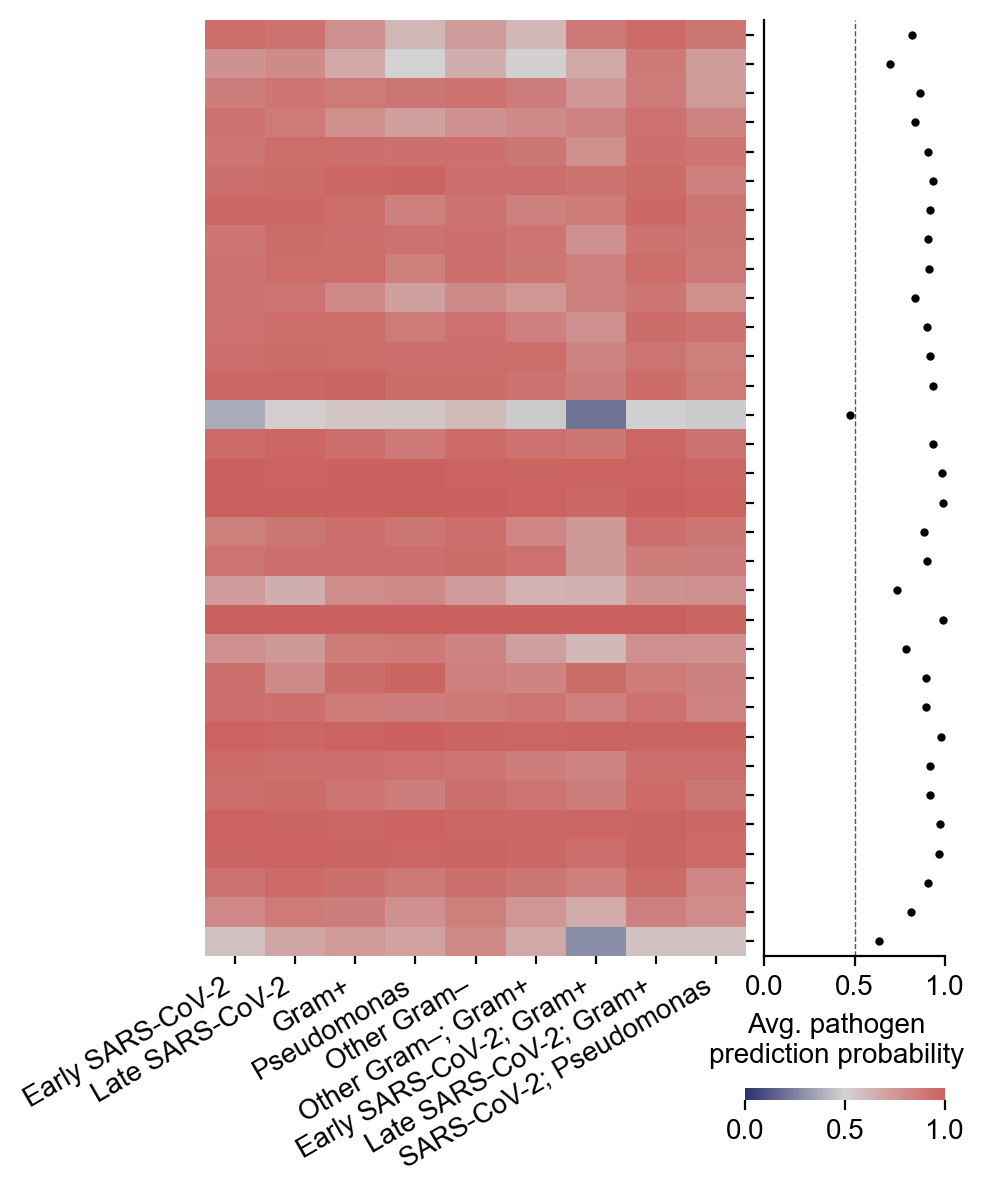

In [16]:
fig, axes = plt.subplots(figsize=(5, 6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0.05, width_ratios=(3, 1)))

ax = axes[0]

pleasant_blue = '#2a306c'  # Steel Blue
pleasant_red = '#cb615e'   # Indian Red
colors = [pleasant_blue, 'lightgray', pleasant_red]
n_bins = 255
cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

cbar_ax = fig.add_axes((0.75, 0.08, 0.2, 0.01))

sns.heatmap(
    path_neg_heatmap.loc[:, TASK_ORDER],
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=[],
    yticklabels=[],
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    ),
)

ax.set_yticks(np.arange(path_neg_heatmap.shape[0]) + 0.5)
ax.tick_params(right=True, left=False, size=3)

x_ticks = []
x_tick_labels = []
for i, task in enumerate(TASK_ORDER):
    x_ticks.append(i + 0.5)
    x_tick_labels.append(TASKS_MAP[task])

ax.set_xticks(x_ticks, labels=x_tick_labels, ha='right', rotation=30)

ax.set_xlabel('')
ax.set_ylabel('')

ax = axes[1]
ax.tick_params(left=False)
ax.axvline(0.5, c='#555', lw=0.5, ls='--')
ax.spines[['top', 'right']].set_visible(False)

avg_preds = path_neg_heatmap.loc[:, TASK_ORDER].mean(axis=1).to_frame(name='avg_prob')
avg_preds['idx'] = np.arange(avg_preds.shape[0]) + 0.5

ax.scatter(avg_preds.avg_prob, avg_preds.idx, s=4, c='k', zorder=5, clip_on=False)
ax.set_xlim(0, 1)

ax.set_xlabel('Avg. pathogen\nprediction probability', x=0.4)
fig.subplots_adjust(top=0.98, right=0.95, bottom=0.2, left=0.21)
fig.savefig('00_plots/06b_path_neg_heatmap.pdf')

/tmp/ipykernel_88817/1067463138.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


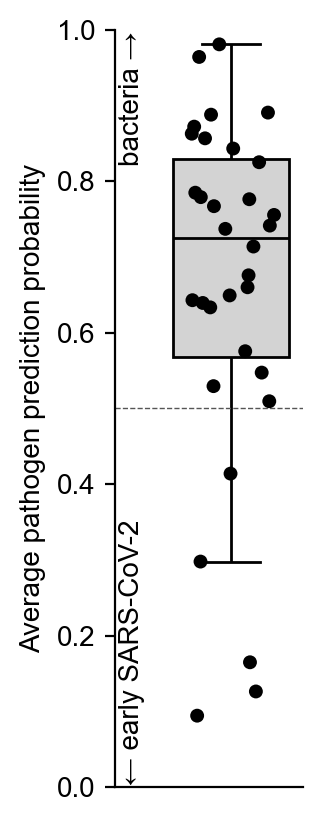

In [14]:
VB_TASK = ['viral_vs_bacterial']

fig, ax = plt.subplots(figsize=(1.5, 4), constrained_layout=True)
sns.boxplot(
    data=path_neg_heatmap.loc[:, VB_TASK].melt(),
    x='task',
    y='value',
    showfliers=False,
    color='lightgray',
    order=VB_TASK,
    linecolor='k',
)
sns.stripplot(
    data=path_neg_heatmap.loc[:, VB_TASK].melt(),
    x='task',
    y='value',
    palette=['k'],
    order=VB_TASK,
    jitter=0.3
)
# x_ticks = []
# x_tick_labels = []
# for i, task in enumerate(VB_TASK):
#     x_ticks.append(i)
#     x_tick_labels.append(TASKS_MAP[task])

# for i in range(len(TASK_ORDER)):
#     ax.axvline(x=i * 4, c='w', lw=1)

ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Average pathogen prediction probability')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 1)
ax.set_xlim(-0.8)
ax.annotate(
    '← early SARS-CoV-2',
    xy=(-0.8, 0),
    xytext=(4, 2),
    textcoords='offset pixels',
    rotation=90,
    ha='left',
    va='bottom'
)
ax.annotate(
    'bacteria →',
    xy=(-0.8, 1),
    xytext=(4, -2),
    textcoords='offset pixels',
    rotation=90,
    ha='left',
    va='top'
)
ax.axhline(0.5, c='#555', lw=0.5, ls='--')
fig.savefig('00_plots/06b_path_neg_boxplot_viral_bac.pdf')